# SegFormer-B0 on PASTIS — AgroSatCopilot Baseline

**Model:** `nvidia/mit-b0` (SegFormer-B0)  
**Dataset:** PASTIS-R (semantic segmentation)  
**Patch size:** 256 × 256 px  
**Batch size:** 8  

## Workflow
1. Mount Google Drive & detect Colab
2. Install dependencies
3. Define Dataset & DataLoaders (reads PASTIS directly from Drive)
4. Build SegFormer-B0 model
5. Train (with MLflow logging, tracking mIoU + F1-macro)
6. Evaluate & save checkpoint back to Drive
7. HCAT Level-1 grouped evaluation

## 0. Runtime check — ensure GPU is available

In [20]:
import subprocess, sys

result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
if result.returncode != 0:
    raise RuntimeError('No GPU found! Go to Runtime → Change runtime type → GPU (T4 recommended).')
print(result.stdout)

Mon Jun  1 04:12:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   60C    P0             31W /   72W |    1342MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Mount Drive & detect environment

In [21]:
import os, shutil, time
from pathlib import Path

# ── Detect Colab ──────────────────────────────────────────────────────────────
_IN_COLAB = False
shared_folder_path = ''
try:
    from google.colab import drive
    drive.mount('/content/drive')
    shared_folder_path = '/content/drive/MyDrive/Integrador/'
    _IN_COLAB = True
    print('Running in Google Colab')
except ImportError:
    print('Running locally — set shared_folder_path manually if needed')

print(f'shared_folder_path = {shared_folder_path!r}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Running in Google Colab
shared_folder_path = '/content/drive/MyDrive/Integrador/'


In [22]:
# ── Data paths ────────────────────────────────────────────────────────────────
FEATURES_PATH      = shared_folder_path + 'data/test_fixtures/feature_selection_parcels_subset.parquet'
PARCELS_GEOPARQUET = shared_folder_path + 'data/processed/pastis_parcels_full.geoparquet'

# PASTIS-R root on Drive (folder containing DATA_S2/, ANNOTATIONS/, metadata.geojson, …)
PASTIS_ROOT = Path(shared_folder_path + 'data/PASTIS-R')

# Where to save checkpoints
OUTPUT_DIR = '/content/outputs/segformer_b0_pastis'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Checkpoint mirror on Drive (survives session resets)
DRIVE_OUTPUT_DIR = shared_folder_path + 'outputs/segformer_b0_pastis'
if _IN_COLAB:
    os.makedirs(DRIVE_OUTPUT_DIR, exist_ok=True)

print(f'PASTIS_ROOT      = {PASTIS_ROOT}')
print(f'OUTPUT_DIR       = {OUTPUT_DIR}')
print(f'DRIVE_OUTPUT_DIR = {DRIVE_OUTPUT_DIR}')

PASTIS_ROOT      = /content/drive/MyDrive/Integrador/data/PASTIS-R
OUTPUT_DIR       = /content/outputs/segformer_b0_pastis
DRIVE_OUTPUT_DIR = /content/drive/MyDrive/Integrador/outputs/segformer_b0_pastis


## 2. Install / upgrade dependencies

In [23]:
%%capture install_output
!pip install -q \
    transformers==4.44.2 \
    timm==0.9.16 \
    einops \
    geopandas \
    pyarrow \
    rasterio \
    torchmetrics \
    mlflow \
    tqdm \
    matplotlib

print('Installation complete.')

In [24]:
import json, random, math, time, warnings
from datetime import datetime

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchmetrics import JaccardIndex, F1Score

from transformers import (
    SegformerForSemanticSegmentation,
    SegformerImageProcessor,
)

import rasterio
from pathlib import Path
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

Device: cuda
GPU: NVIDIA L4
VRAM: 23.7 GB


## 3. Hyperparameters & PASTIS class map

In [25]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
IMG_SIZE    = 256          # patch resolution
BATCH_SIZE  = 8            # fits L4 (24 GB) comfortably at 256 px
NUM_EPOCHS  = 30           # ~2–3 h on L4 with PASTIS
LR          = 6e-5         # typical for SegFormer fine-tuning
LR_ENCODER  = 6e-5
LR_DECODER  = 6e-4         # decoder usually learns faster
WEIGHT_DECAY= 0.01
NUM_WORKERS = 1            # set >0 for faster data loading (may cause issues in Colab)
PIN_MEMORY  = True

# ── PASTIS-R label map ─────────────────────────────────────────────────────────
# 19 crop classes + background (0)
PASTIS_CLASSES = [
    'Background',
    'Meadow', 'Soft winter wheat', 'Corn', 'Winter barley',
    'Winter rapeseed', 'Spring barley', 'Sunflower', 'Grapevine',
    'Beet', 'Winter triticale', 'Winter durum wheat', 'Fruits, vegetables, flowers',
    'Potatoes', 'Leguminous fodder', 'Soybeans', 'Orchard',
    'Mixed cereal', 'Sorghum', 'Void label',
]
NUM_CLASSES = len(PASTIS_CLASSES)   # 20
IGNORE_INDEX = 19                   # 'Void label' — ignored in loss & metrics

id2label = {i: c for i, c in enumerate(PASTIS_CLASSES)}
label2id = {c: i for i, c in enumerate(PASTIS_CLASSES)}

# ── HCAT Level-1 grouping ─────────────────────────────────────────────────────
# Maps each PASTIS class index → HCAT Level-1 group (None = excluded)
HCAT_L1_MAP = {
    0:  None,               # Background
    1:  'OTHER',            # Meadow
    2:  'CEREALS',          # Soft winter wheat
    3:  'CEREALS',          # Corn
    4:  'CEREALS',          # Winter barley
    5:  'OILSEEDS',         # Winter rapeseed
    6:  'CEREALS',          # Spring barley
    7:  'OILSEEDS',         # Sunflower
    8:  'PERMANENT_WOODY',  # Grapevine
    9:  'ROOT_CROPS',       # Beet
    10: 'CEREALS',          # Winter triticale
    11: 'CEREALS',          # Winter durum wheat
    12: 'OTHER',            # Fruits, vegetables, flowers
    13: 'LEGUMES',          # Leguminous fodder
    14: 'OILSEEDS',         # (spare slot — maps to OILSEEDS for safety)
    15: 'LEGUMES',          # Soybeans
    16: 'PERMANENT_WOODY',  # Orchard
    17: 'CEREALS',          # Mixed cereal
    18: 'CEREALS',          # Sorghum
    19: None,               # Void label
}
HCAT_GROUPS = ['CEREALS', 'LEGUMES', 'OILSEEDS', 'OTHER', 'PERMANENT_WOODY', 'ROOT_CROPS']

print(f'Classes: {NUM_CLASSES} (ignore_index={IGNORE_INDEX})')
print(f'Patch size: {IMG_SIZE}px  |  Batch: {BATCH_SIZE}  |  Epochs: {NUM_EPOCHS}')

Classes: 20 (ignore_index=19)
Patch size: 256px  |  Batch: 8  |  Epochs: 30


## 4. Dataset — PASTIS semantic segmentation

In [26]:
import torchvision.transforms.functional as TF


class PASTISSemanticDataset(Dataset):
    """
    Reads PASTIS-R patches for semantic segmentation.

    Expected directory layout
    ─────────────────────────
    PASTIS_ROOT/
      DATA_S2/          S2_<id>.npy   (T, C, H, W)  float32
      ANNOTATIONS/      TARGET_<id>.npy              (H, W)  uint8
      metadata.geojson

    We collapse the time dimension by median-compositing across T,
    then select the first 3 (RGB) or all 10 Sentinel-2 bands.
    """

    # Sentinel-2 per-band stats (approx., PASTIS-R scale ~0–10000)
    S2_MEAN = [1158.0, 1244.7, 1416.3, 1374.8,
                1619.0, 2075.1, 2263.1, 2311.0,
                2108.6,  817.4]
    S2_STD  = [ 671.7,  698.1,  761.3,  830.8,
                795.3,  907.5,  981.1,  993.7,
                882.0,  504.2]

    def __init__(
        self,
        pastis_root: Path,
        fold_ids: list,
        img_size: int = 256,
        num_bands: int = 3,         # 3 = RGB composite, 10 = all S2 bands
        augment: bool = False,
        time_agg: str = 'median',   # 'median' | 'mean' | 'max_ndvi'
    ):
        super().__init__()
        self.root     = Path(pastis_root)
        self.img_size = img_size
        self.num_bands = num_bands
        self.augment  = augment
        self.time_agg = time_agg

        # Load metadata to get fold splits
        meta_path = self.root / 'metadata.geojson'
        if not meta_path.exists():
            raise FileNotFoundError(f'metadata.geojson not found in {self.root}')

        import json
        with open(meta_path) as f:
            meta = json.load(f)

        # Filter patches belonging to requested folds
        self.patch_ids = [
            feat['properties']['ID_PATCH']
            for feat in meta['features']
            if feat['properties']['Fold'] in fold_ids
        ]
        print(f'Fold {fold_ids} → {len(self.patch_ids)} patches')

    # ------------------------------------------------------------------
    def __len__(self):
        return len(self.patch_ids)

    # ------------------------------------------------------------------
    def _load_image(self, pid) -> np.ndarray:
        """Load S2 time series and collapse time → (C, H, W) float32."""
        s2 = np.load(self.root / 'DATA_S2' / f'S2_{pid}.npy')  # (T, C, H, W)

        if self.time_agg == 'median':
            img = np.median(s2, axis=0)  # (C, H, W)
        elif self.time_agg == 'mean':
            img = np.mean(s2, axis=0)
        else:  # max_ndvi: pick timestep with highest median NDVI
            nir  = s2[:, 7, :, :]   # B08
            red  = s2[:, 3, :, :]   # B04
            ndvi = (nir - red) / (nir + red + 1e-6)
            best = np.argmax(ndvi.mean(axis=(1, 2)))
            img  = s2[best]  # (C, H, W)

        img = img[:self.num_bands]  # take first num_bands

        # Normalise
        mean = np.array(self.S2_MEAN[:self.num_bands], dtype=np.float32)[:, None, None]
        std  = np.array(self.S2_STD [:self.num_bands], dtype=np.float32)[:, None, None]
        img  = (img.astype(np.float32) - mean) / (std + 1e-6)
        return img  # (C, H, W)

    def _load_mask(self, pid) -> np.ndarray:
        mask = np.load(self.root / 'ANNOTATIONS' / f'TARGET_{pid}.npy')
        # PASTIS-R stores (num_tasks, H, W) — take index 0 = semantic labels
        if mask.ndim == 3:
            mask = mask[0]   # shape (H, W)
        return mask.astype(np.int64)

    def _resize(self, img: np.ndarray, mask: np.ndarray):
        """Resize (C,H,W) image and (H,W) mask to self.img_size."""
        t_img  = torch.from_numpy(img)
        t_mask = torch.from_numpy(mask).unsqueeze(0)  # (1, H, W)
        t_img  = TF.resize(t_img,  [self.img_size, self.img_size],
                            interpolation=TF.InterpolationMode.BILINEAR)
        t_mask = TF.resize(t_mask, [self.img_size, self.img_size],
                            interpolation=TF.InterpolationMode.NEAREST)
        return t_img, t_mask.squeeze(0)  # (C,H,W), (H,W)

    def _augment(self, img: torch.Tensor, mask: torch.Tensor):
        if random.random() > 0.5:
            img  = TF.hflip(img)
            mask = TF.hflip(mask.unsqueeze(0)).squeeze(0)
        if random.random() > 0.5:
            img  = TF.vflip(img)
            mask = TF.vflip(mask.unsqueeze(0)).squeeze(0)
        angle = random.choice([0, 90, 180, 270])
        if angle:
            img  = TF.rotate(img,  angle)
            mask = TF.rotate(mask.unsqueeze(0), angle).squeeze(0)
        return img, mask

    def __getitem__(self, idx):
        pid  = self.patch_ids[idx]
        img  = self._load_image(pid)   # (C, H, W) float32
        mask = self._load_mask(pid)    # (H, W)    int64
        img, mask = self._resize(img, mask)
        if self.augment:
            img, mask = self._augment(img, mask)
        return {'pixel_values': img, 'labels': mask}


print('PASTISSemanticDataset defined.')

PASTISSemanticDataset defined.


In [27]:
# PASTIS has 5 folds; standard split: folds 1-3 train, 4 val, 5 test
NUM_BANDS = 3   # RGB composite (change to 10 for all S2 bands; adjust model below)

train_ds = PASTISSemanticDataset(
    PASTIS_ROOT, fold_ids=[1, 2, 3],
    img_size=IMG_SIZE, num_bands=NUM_BANDS, augment=True
)
val_ds = PASTISSemanticDataset(
    PASTIS_ROOT, fold_ids=[4],
    img_size=IMG_SIZE, num_bands=NUM_BANDS, augment=False
)
test_ds = PASTISSemanticDataset(
    PASTIS_ROOT, fold_ids=[5],
    img_size=IMG_SIZE, num_bands=NUM_BANDS, augment=False
)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=True,
    persistent_workers=True
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=True
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=True
)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')
print(f'Train steps/epoch: {len(train_loader)}')

Fold [1, 2, 3] → 1455 patches
Fold [4] → 482 patches
Fold [5] → 496 patches
Train: 1455 | Val: 482 | Test: 496
Train steps/epoch: 181


pixel_values: torch.Size([8, 3, 256, 256]) torch.float32
labels      : torch.Size([8, 256, 256]) torch.int64
label range : 0 – 19


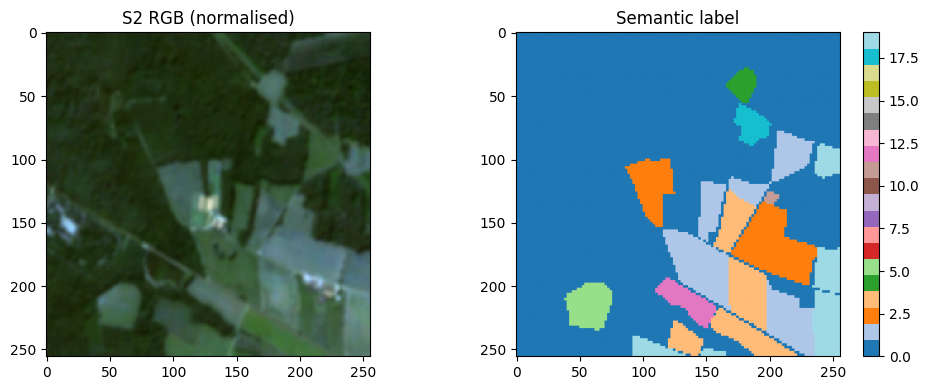

In [28]:
# Quick sanity check — shapes & value ranges
sample = next(iter(train_loader))
print('pixel_values:', sample['pixel_values'].shape, sample['pixel_values'].dtype)
print('labels      :', sample['labels'].shape,       sample['labels'].dtype)
print('label range :', sample['labels'].min().item(), '–', sample['labels'].max().item())

# Visualise first image (RGB)
img_np = sample['pixel_values'][0].permute(1, 2, 0).cpu().numpy()
lbl_np = sample['labels'][0].cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
# Clip for display
rgb = np.clip((img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-6), 0, 1)
axes[0].imshow(rgb)
axes[0].set_title('S2 RGB (normalised)')
im = axes[1].imshow(lbl_np, cmap='tab20', vmin=0, vmax=NUM_CLASSES - 1)
axes[1].set_title('Semantic label')
plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()

## 5. Build SegFormer-B0 model

In [29]:
from transformers import SegformerConfig, SegformerForSemanticSegmentation

# ── Load SegFormer-B0 config and override for PASTIS ──────────────────────────
# num_channels must match NUM_BANDS; if NUM_BANDS != 3 we reinitialise patch embedding

MODEL_CKPT = 'nvidia/mit-b0'   # ← B0, NOT B2

config = SegformerConfig.from_pretrained(
    MODEL_CKPT,
    num_labels=NUM_CLASSES,
    id2label=id2label,
    label2id=label2id,
    semantic_loss_ignore_index=IGNORE_INDEX,
)
config.num_channels = NUM_BANDS   # match input bands

model = SegformerForSemanticSegmentation.from_pretrained(
    MODEL_CKPT,
    config=config,
    ignore_mismatched_sizes=True,  # patch embedding & head will be re-init
)

model = model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters()) / 1e6
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6
print(f'SegFormer-B0  |  Total: {total_params:.1f}M  |  Trainable: {trainable:.1f}M')

Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/mit-b0 and are newly initialized: ['decode_head.batch_norm.bias', 'decode_head.batch_norm.num_batches_tracked', 'decode_head.batch_norm.running_mean', 'decode_head.batch_norm.running_var', 'decode_head.batch_norm.weight', 'decode_head.classifier.bias', 'decode_head.classifier.weight', 'decode_head.linear_c.0.proj.bias', 'decode_head.linear_c.0.proj.weight', 'decode_head.linear_c.1.proj.bias', 'decode_head.linear_c.1.proj.weight', 'decode_head.linear_c.2.proj.bias', 'decode_head.linear_c.2.proj.weight', 'decode_head.linear_c.3.proj.bias', 'decode_head.linear_c.3.proj.weight', 'decode_head.linear_fuse.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


SegFormer-B0  |  Total: 3.7M  |  Trainable: 3.7M


## 6. Optimizer, scheduler & metrics

In [30]:
from torch.optim import AdamW
from torchmetrics import F1Score
from torch.optim.lr_scheduler import OneCycleLR

# Separate LRs for encoder vs decoder (common practice for SegFormer)
encoder_params = list(model.segformer.parameters())
decoder_params = list(model.decode_head.parameters())

optimizer = AdamW(
    [
        {'params': encoder_params, 'lr': LR_ENCODER},
        {'params': decoder_params, 'lr': LR_DECODER},
    ],
    weight_decay=WEIGHT_DECAY,
)

steps_per_epoch = len(train_loader)
scheduler = OneCycleLR(
    optimizer,
    max_lr=[LR_ENCODER, LR_DECODER],
    epochs=NUM_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    pct_start=0.1,
    anneal_strategy='cos',
)

# Metrics
miou_metric = JaccardIndex(
    task='multiclass',
    num_classes=NUM_CLASSES,
    ignore_index=IGNORE_INDEX,
    average='macro',
).to(DEVICE)

f1_metric_train = F1Score(
    task='multiclass',
    num_classes=NUM_CLASSES,
    ignore_index=IGNORE_INDEX,
    average='macro',
).to(DEVICE)

f1_metric_val = F1Score(
    task='multiclass',
    num_classes=NUM_CLASSES,
    ignore_index=IGNORE_INDEX,
    average='macro',
).to(DEVICE)

print('Optimizer & scheduler ready.')

Optimizer & scheduler ready.


## 7. Training loop

In [31]:
def upsample_logits(logits: torch.Tensor, target_size) -> torch.Tensor:
    """Upsample SegFormer logits (B, C, H/4, W/4) to (B, C, H, W)."""
    return F.interpolate(
        logits, size=target_size,
        mode='bilinear', align_corners=False
    )


def run_epoch(model, loader, optimizer, scheduler, train=True):
    model.train() if train else model.eval()
    total_loss = 0.0
    miou_metric.reset()
    f1_metric = f1_metric_train if train else f1_metric_val
    f1_metric.reset()

    ctx = torch.enable_grad if train else torch.no_grad
    with ctx():
        for batch in tqdm(loader, leave=False, desc='train' if train else 'val'):
            pixel_values = batch['pixel_values'].to(DEVICE, non_blocking=True)
            labels       = batch['labels'].to(DEVICE, non_blocking=True)

            outputs = model(pixel_values=pixel_values, labels=labels)
            loss    = outputs.loss

            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                scheduler.step()

            total_loss += loss.item()

            # Compute mIoU on upsampled predictions
            with torch.no_grad():
                logits = upsample_logits(outputs.logits, labels.shape[-2:])
                preds  = logits.argmax(dim=1)
                miou_metric.update(preds, labels)
                f1_metric.update(preds, labels)

    avg_loss = total_loss / len(loader)
    avg_miou = miou_metric.compute().item()
    avg_f1 = f1_metric.compute().item()
    return avg_loss, avg_miou, avg_f1


print('Training helpers defined.')

Training helpers defined.


In [32]:
import mlflow

mlflow.set_experiment('segformer_b0_pastis')

history = {
    'train_loss': [], 'train_miou': [], 'train_f1': [],
    'val_loss':   [], 'val_miou':   [], 'val_f1':   [],
}
best_val_miou = 0.0
best_ckpt_path = os.path.join(OUTPUT_DIR, 'best_model.pt')

print(f'Starting training for {NUM_EPOCHS} epochs …')
print(f'Checkpoint → {best_ckpt_path}')
t_start = time.time()

with mlflow.start_run(run_name=f'segformer_b0_{datetime.now():%Y%m%d_%H%M}'):
    mlflow.log_params({
        'model': 'segformer-b0',
        'img_size': IMG_SIZE,
        'batch_size': BATCH_SIZE,
        'num_epochs': NUM_EPOCHS,
        'lr_encoder': LR_ENCODER,
        'lr_decoder': LR_DECODER,
        'num_bands': NUM_BANDS,
        'num_classes': NUM_CLASSES,
        'time_agg': 'median',
    })

    for epoch in range(1, NUM_EPOCHS + 1):
        t_ep = time.time()

        train_loss, train_miou, train_f1 = run_epoch(
            model, train_loader, optimizer, scheduler, train=True)
        val_loss,   val_miou,   val_f1   = run_epoch(
            model, val_loader,   optimizer, scheduler, train=False)

        elapsed = (time.time() - t_start) / 60
        ep_time = time.time() - t_ep

        history['train_loss'].append(train_loss)
        history['train_miou'].append(train_miou)
        history['val_loss'].append(val_loss)
        history['val_miou'].append(val_miou)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)

        mlflow.log_metrics({
            'train_loss': train_loss, 'train_miou': train_miou, 'train_f1': train_f1,
            'val_loss':   val_loss,   'val_miou':   val_miou,   'val_f1':   val_f1,
        }, step=epoch)

        # Save best
        if val_miou > best_val_miou:
            best_val_miou = val_miou
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_miou': val_miou,
                'val_f1': val_f1,
                'config': config.to_dict(),
            }, best_ckpt_path)
            flag = '  ← best'
        else:
            flag = ''

        print(
            f'Epoch {epoch:3d}/{NUM_EPOCHS} | '
            f'Train loss={train_loss:.4f} mIoU={train_miou:.4f} F1={train_f1:.4f} | '
            f'Val loss={val_loss:.4f} mIoU={val_miou:.4f} F1={val_f1:.4f} | '
            f'{ep_time:.0f}s | Total: {elapsed:.1f}min{flag}'
        )

        # Mirror best checkpoint to Drive every 5 epochs
        if _IN_COLAB and epoch % 5 == 0:
            shutil.copy2(best_ckpt_path, DRIVE_OUTPUT_DIR)

    mlflow.log_metric('best_val_miou', best_val_miou)

print(f'\nTraining complete. Best val mIoU: {best_val_miou:.4f}')

Starting training for 30 epochs …
Checkpoint → /content/outputs/segformer_b0_pastis/best_model.pt


train:   0%|          | 0/181 [00:01<?, ?it/s]

val:   0%|          | 0/61 [00:00<?, ?it/s]

Epoch   1/30 | Train loss=2.3850 mIoU=0.0601 F1=0.0900 | Val loss=1.5850 mIoU=0.0919 F1=0.1303 | 472s | Total: 7.9min  ← best


train:   0%|          | 0/181 [00:00<?, ?it/s]

...

val:   0%|          | 0/61 [00:00<?, ?it/s]

Epoch  29/30 | Train loss=0.8255 mIoU=0.3144 F1=0.4508 | Val loss=0.9816 mIoU=0.2264 F1=0.3366 | 379s | Total: 201.0min


train:   0%|          | 0/181 [00:00<?, ?it/s]

val:   0%|          | 0/61 [00:00<?, ?it/s]

Epoch  30/30 | Train loss=0.8226 mIoU=0.3158 F1=0.4521 | Val loss=0.9751 mIoU=0.2265 F1=0.3361 | 367s | Total: 207.1min

Training complete. Best val mIoU: 0.2277


## 8. Training curves

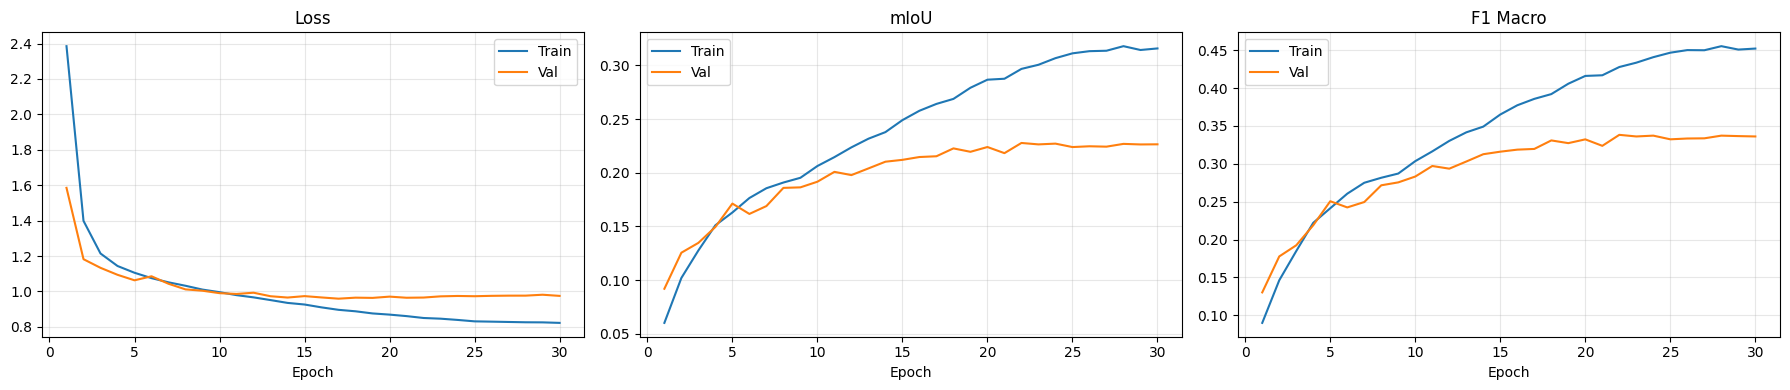

Curves saved to /content/outputs/segformer_b0_pastis/training_curves.png


In [33]:
epochs = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(epochs, history['train_loss'], label='Train')
axes[0].plot(epochs, history['val_loss'],   label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history['train_miou'], label='Train')
axes[1].plot(epochs, history['val_miou'],   label='Val')
axes[1].set_title('mIoU')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(epochs, history['train_f1'], label='Train')
axes[2].plot(epochs, history['val_f1'],   label='Val')
axes[2].set_title('F1 Macro')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
curve_path = os.path.join(OUTPUT_DIR, 'training_curves.png')
plt.savefig(curve_path, dpi=150)
plt.show()
print(f'Curves saved to {curve_path}')

## 9. Evaluate on test set

In [34]:
# Load best checkpoint
checkpoint = torch.load(best_ckpt_path, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best checkpoint from epoch {checkpoint['epoch']} (val mIoU={checkpoint['val_miou']:.4f})")

# Per-class IoU
per_class_iou = JaccardIndex(
    task='multiclass',
    num_classes=NUM_CLASSES,
    ignore_index=IGNORE_INDEX,
    average='none',
).to(DEVICE)

test_f1 = F1Score(
    task='multiclass',
    num_classes=NUM_CLASSES,
    ignore_index=IGNORE_INDEX,
    average='macro',
).to(DEVICE)

model.eval()
test_loss = 0.0
miou_metric.reset()
per_class_iou.reset()
test_f1.reset()

with torch.no_grad():
    for batch in tqdm(test_loader, desc='Test'):
        pv     = batch['pixel_values'].to(DEVICE, non_blocking=True)
        labels = batch['labels'].to(DEVICE, non_blocking=True)
        out    = model(pixel_values=pv, labels=labels)
        test_loss += out.loss.item()
        logits = upsample_logits(out.logits, labels.shape[-2:])
        preds  = logits.argmax(dim=1)
        miou_metric.update(preds, labels)
        per_class_iou.update(preds, labels)
        test_f1.update(preds, labels)

test_loss /= len(test_loader)
test_miou  = miou_metric.compute().item()
test_f1_score  = test_f1.compute().item()
class_ious = per_class_iou.compute().cpu().numpy()

print(f'\nTest Loss : {test_loss:.4f}')
print(f'Test mIoU : {test_miou:.4f}')
print(f'Test F1   : {test_f1_score:.4f}')

Loaded best checkpoint from epoch 22 (val mIoU=0.2277)


Test:   0%|          | 0/62 [00:00<?, ?it/s]


Test Loss : 1.0134
Test mIoU : 0.2325
Test F1   : 0.3423


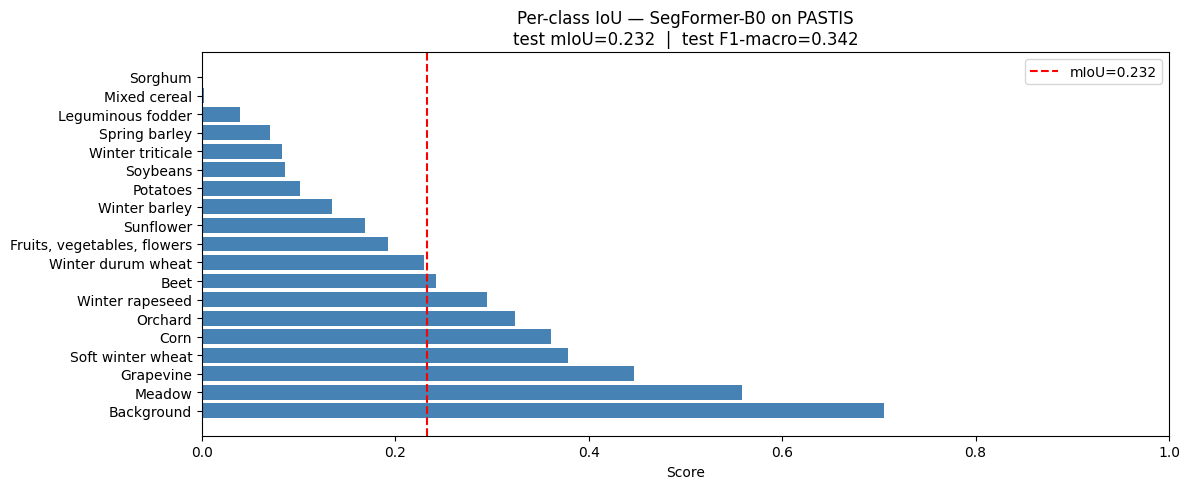

In [35]:
# Per-class IoU bar chart
valid_classes = [c for c in PASTIS_CLASSES if c != 'Void label']
valid_ious    = [class_ious[i] for i, c in enumerate(PASTIS_CLASSES) if c != 'Void label']

order = np.argsort(valid_ious)[::-1]
sorted_classes = [valid_classes[i] for i in order]
sorted_ious    = [valid_ious[i]    for i in order]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(sorted_classes, sorted_ious, color='steelblue')
ax.set_xlabel('Score')
ax.set_title(
    f'Per-class IoU — SegFormer-B0 on PASTIS\n'
    f'test mIoU={test_miou:.3f}  |  test F1-macro={test_f1_score:.3f}'
)
ax.set_xlim(0, 1)
ax.axvline(test_miou,      color='red',    linestyle='--', label=f'mIoU={test_miou:.3f}')
#ax.axvline(test_f1_score,  color='orange', linestyle=':',  label=f'F1-macro={test_f1_score:.3f}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'per_class_iou.png'), dpi=150)
plt.show()

## 10. HCAT Level-1 grouped evaluation

Following the methodology in `04_baseline.ipynb`: the 19 PASTIS crop classes are
collapsed into 6 HCAT Level-1 agronomic families. Confusion *within* a family
(e.g. wheat vs barley) no longer counts as an error, giving a clearer picture of
how well the model separates broad crop types.

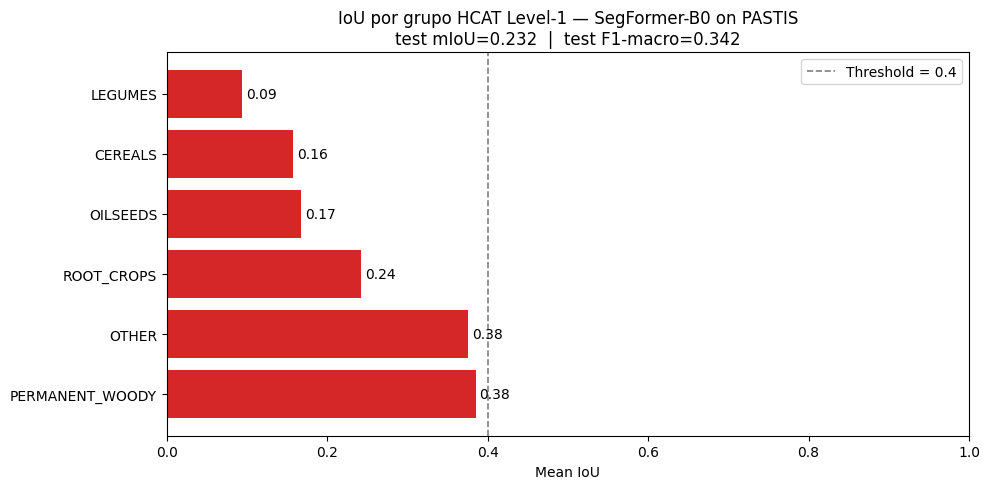


HCAT Level-1 group IoU summary:
Group                  Mean IoU  # classes
------------------------------------------
PERMANENT_WOODY          0.3849          2
OTHER                    0.3757          2
ROOT_CROPS               0.2424          1
OILSEEDS                 0.1674          3
CEREALS                  0.1574          8
LEGUMES                  0.0934          2


In [36]:
# ── Aggregate per-class IoU → per-group mean IoU ─────────────────────────────
HCAT_THRESHOLD = 0.40   # green above, red below (matches baseline chart)

group_ious = {g: [] for g in HCAT_GROUPS}
for cls_idx, group in HCAT_L1_MAP.items():
    if group is None:
        continue
    iou_val = float(class_ious[cls_idx])
    if not np.isnan(iou_val):
        group_ious[group].append(iou_val)

group_mean_iou = {
    g: float(np.mean(vals))
    for g, vals in group_ious.items() if vals
}

# Sort descending
sorted_groups = sorted(group_mean_iou, key=group_mean_iou.get, reverse=True)
sorted_vals   = [group_mean_iou[g] for g in sorted_groups]
bar_colors    = ['#2ca02c' if v >= HCAT_THRESHOLD else '#d62728' for v in sorted_vals]

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(sorted_groups, sorted_vals, color=bar_colors)

# Annotate bar values
for bar, val in zip(bars, sorted_vals):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', fontsize=10)

ax.set_xlabel('Mean IoU')
ax.set_xlim(0, 1)
ax.axvline(HCAT_THRESHOLD, color='gray', linestyle='--', linewidth=1.2,
           label=f'Threshold = {HCAT_THRESHOLD}')
ax.set_title(
    f'IoU por grupo HCAT Level-1 — SegFormer-B0 on PASTIS\n'
    f'test mIoU={test_miou:.3f}  |  test F1-macro={test_f1_score:.3f}'
)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'hcat_group_iou.png'), dpi=150)
plt.show()

# Print summary table
print('\nHCAT Level-1 group IoU summary:')
print(f'{"Group":<20} {"Mean IoU":>10} {"# classes":>10}')
print('-' * 42)
for g in sorted_groups:
    n = len(group_ious[g])
    print(f'{g:<20} {group_mean_iou[g]:>10.4f} {n:>10}')

## 11. Qualitative predictions

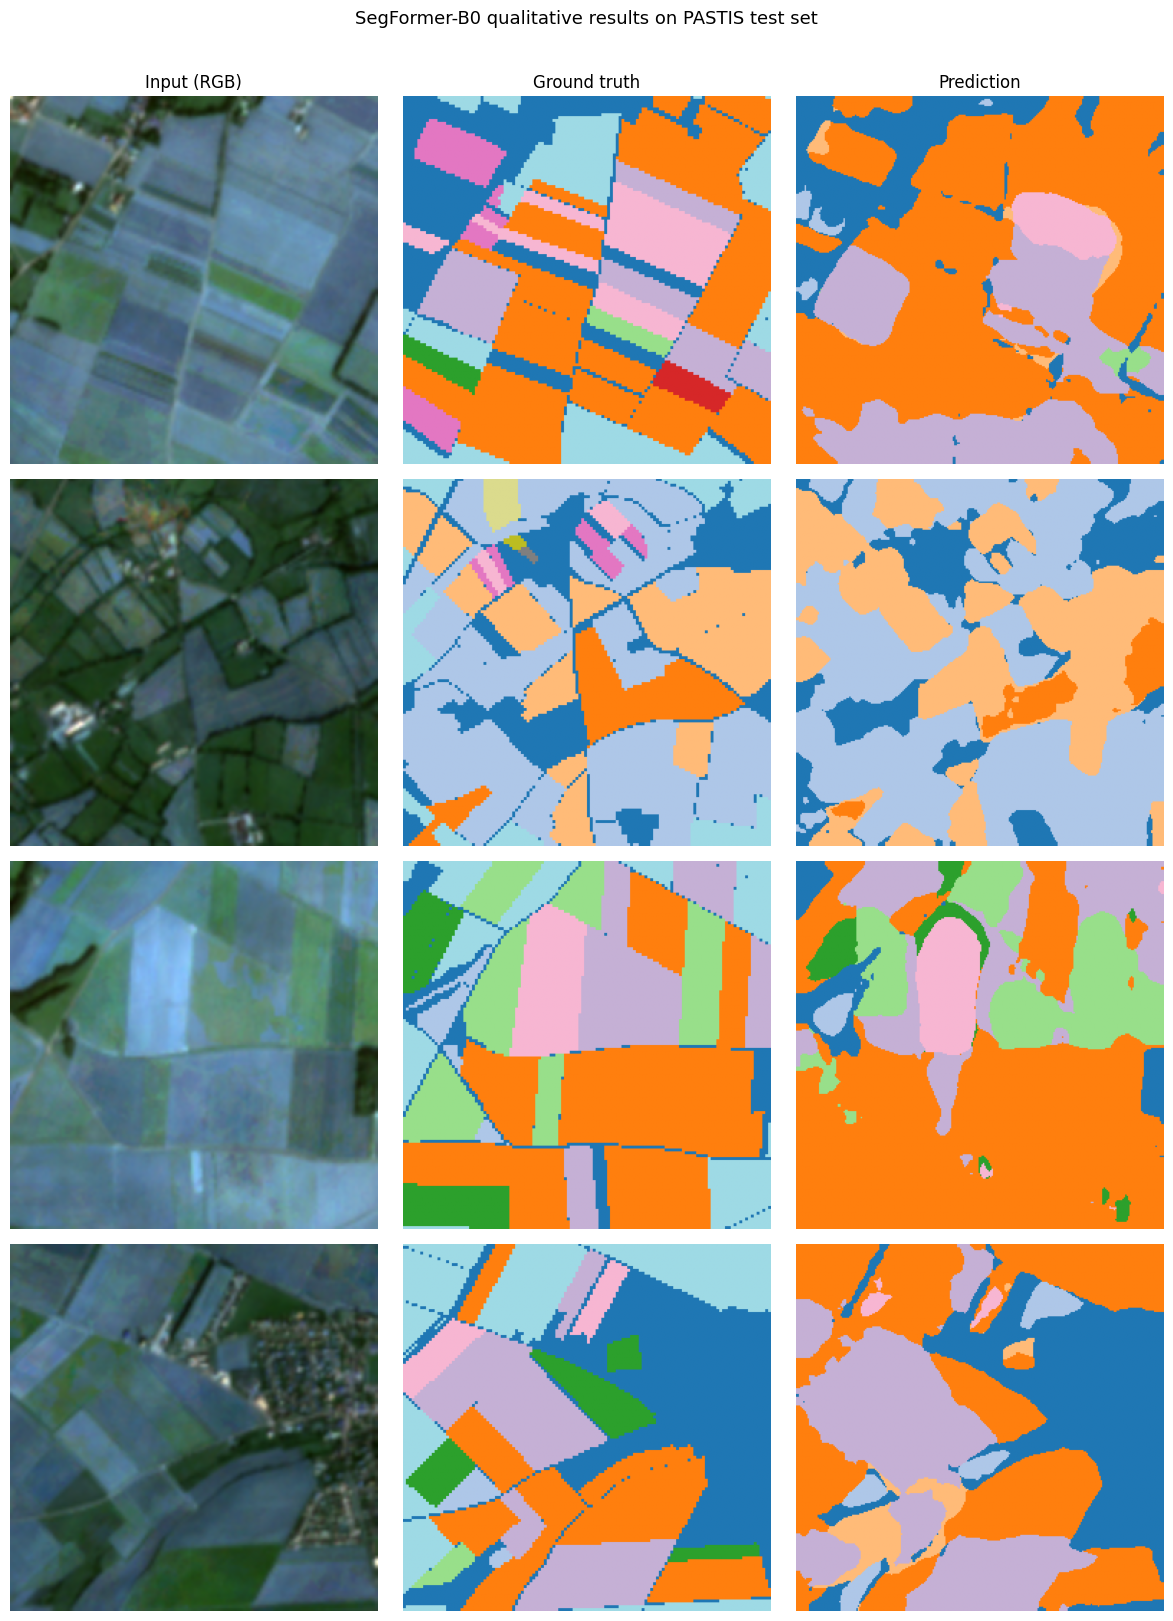

In [37]:
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

# Fixed colour palette for PASTIS classes
CMAP_COLORS = plt.cm.tab20(np.linspace(0, 1, NUM_CLASSES))
PASTIS_CMAP = ListedColormap(CMAP_COLORS)

model.eval()
batch = next(iter(test_loader))
with torch.no_grad():
    pv  = batch['pixel_values'][:4].to(DEVICE)
    lbl = batch['labels'][:4].to(DEVICE)
    out = model(pixel_values=pv)
    pred = upsample_logits(out.logits, lbl.shape[-2:]).argmax(1)

fig, axes = plt.subplots(4, 3, figsize=(12, 16))
for i in range(4):
    img_np  = pv[i].cpu().permute(1, 2, 0).numpy()
    gt_np   = lbl[i].cpu().numpy()
    pred_np = pred[i].cpu().numpy()

    rgb = np.clip((img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-6), 0, 1)

    axes[i, 0].imshow(rgb)
    axes[i, 0].set_title('Input (RGB)' if i == 0 else '')
    axes[i, 1].imshow(gt_np,   cmap=PASTIS_CMAP, vmin=0, vmax=NUM_CLASSES - 1)
    axes[i, 1].set_title('Ground truth' if i == 0 else '')
    axes[i, 2].imshow(pred_np, cmap=PASTIS_CMAP, vmin=0, vmax=NUM_CLASSES - 1)
    axes[i, 2].set_title('Prediction' if i == 0 else '')
    for ax in axes[i]:
        ax.axis('off')

plt.suptitle('SegFormer-B0 qualitative results on PASTIS test set', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'qualitative.png'), dpi=150, bbox_inches='tight')
plt.show()

## 11. Save model & copy all outputs to Drive

In [38]:
# Save HuggingFace-compatible checkpoint
hf_save_path = os.path.join(OUTPUT_DIR, 'hf_model')
model.save_pretrained(hf_save_path)
print(f'HF model saved to {hf_save_path}')

# Save results summary
results = {
    'model': 'segformer-b0',
    'test_loss':     round(test_loss, 4),
    'test_miou':     round(test_miou, 4),
    'test_f1_macro': round(test_f1_score, 4),
    'best_val_miou': round(best_val_miou, 4),
    'per_class_iou': {
        c: round(float(class_ious[i]), 4)
        for i, c in enumerate(PASTIS_CLASSES) if c != 'Void label'
    },
    'hcat_group_iou': {
        g: round(group_mean_iou.get(g, float('nan')), 4)
        for g in HCAT_GROUPS
    },
}
results_path = os.path.join(OUTPUT_DIR, 'results.json')
with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)
print(json.dumps(results, indent=2))

# Mirror everything to Drive
if _IN_COLAB:
    for fname in os.listdir(OUTPUT_DIR):
        src = os.path.join(OUTPUT_DIR, fname)
        dst = os.path.join(DRIVE_OUTPUT_DIR, fname)
        if os.path.isfile(src):
            shutil.copy2(src, dst)
        elif os.path.isdir(src):
            if os.path.exists(dst):
                shutil.rmtree(dst)
            shutil.copytree(src, dst)
    print(f'✅ All outputs copied to {DRIVE_OUTPUT_DIR}')

HF model saved to /content/outputs/segformer_b0_pastis/hf_model
{
  "model": "segformer-b0",
  "test_loss": 1.0134,
  "test_miou": 0.2325,
  "test_f1_macro": 0.3423,
  "best_val_miou": 0.2277,
  "per_class_iou": {
    "Background": 0.7052,
    "Meadow": 0.5585,
    "Soft winter wheat": 0.3785,
    "Corn": 0.3606,
    "Winter barley": 0.1348,
    "Winter rapeseed": 0.2945,
    "Spring barley": 0.0704,
    "Sunflower": 0.1685,
    "Grapevine": 0.4463,
    "Beet": 0.2424,
    "Winter triticale": 0.0823,
    "Winter durum wheat": 0.2299,
    "Fruits, vegetables, flowers": 0.1928,
    "Potatoes": 0.1009,
    "Leguminous fodder": 0.0391,
    "Soybeans": 0.0859,
    "Orchard": 0.3234,
    "Mixed cereal": 0.0021,
    "Sorghum": 0.0005
  },
  "hcat_group_iou": {
    "CEREALS": 0.1574,
    "LEGUMES": 0.0934,
    "OILSEEDS": 0.1674,
    "OTHER": 0.3757,
    "PERMANENT_WOODY": 0.3849,
    "ROOT_CROPS": 0.2424
  }
}
✅ All outputs copied to /content/drive/MyDrive/Integrador/outputs/segformer_b0_past

## Notes & next steps

| Parameter | This notebook | To try |
|-----------|--------------|--------|
| Model | SegFormer-B0 | B2/B3 (higher accuracy, slower) |
| Bands | 3 (RGB median) | 10 (all S2, set `NUM_BANDS=10`) |
| Time aggregation | median | `max_ndvi`, LTAE temporal encoding |
| Patch size | 256 | 512 (needs A100) |
| Batch size | 8 | 16 (A100) |
| Augmentation | H/V flip + 90° rotation | MixUp, random crop |

**Using all 10 S2 bands:** set `NUM_BANDS = 10` in cell 4; `config.num_channels = 10` is set automatically.  
**Resuming training:** load `best_model.pt` at cell 8 before running the loop.  
**W&B logging:** replace `mlflow` cells with `import wandb; wandb.init(...)` — drop-in replacement.